In [1]:
pip install scikit-learn==1.3.2 imbalanced-learn==0.11.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 74.1 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 18.2 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.13.0
    Uninstalling imbalanced-learn-0.13.0:
      Successfully uninstalled imbalanced-learn-0.13.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
umap-learn 0.5.9.post2 requires scikit-learn>=1.6, but you have scikit-learn 1.3.2 which is incompatible.
Note: you may need to restart the kernel to use updated packages.


# Import libraries 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score
)

from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from imblearn.over_sampling import SMOTE


# Load Dataset

In [3]:
df = pd.read_csv(
    "/kaggle/input/heart-failure-clinical-data/heart_failure_clinical_records_dataset.csv"
)


# Initial Data Inspection

In [4]:
TARGET = "DEATH_EVENT"

In [5]:
print("Dataset Shape:", df.shape)
print(df.info())

Dataset Shape: (299, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 299 entries, 0 to 298
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       299 non-null    float64
 1   anaemia                   299 non-null    int64  
 2   creatinine_phosphokinase  299 non-null    int64  
 3   diabetes                  299 non-null    int64  
 4   ejection_fraction         299 non-null    int64  
 5   high_blood_pressure       299 non-null    int64  
 6   platelets                 299 non-null    float64
 7   serum_creatinine          299 non-null    float64
 8   serum_sodium              299 non-null    int64  
 9   sex                       299 non-null    int64  
 10  smoking                   299 non-null    int64  
 11  time                      299 non-null    int64  
 12  DEATH_EVENT               299 non-null    int64  
dtypes: float64(3), int64(10)
memory usage: 3

In [6]:
print(df.describe())

              age     anaemia  creatinine_phosphokinase    diabetes  \
count  299.000000  299.000000                299.000000  299.000000   
mean    60.833893    0.431438                581.839465    0.418060   
std     11.894809    0.496107                970.287881    0.494067   
min     40.000000    0.000000                 23.000000    0.000000   
25%     51.000000    0.000000                116.500000    0.000000   
50%     60.000000    0.000000                250.000000    0.000000   
75%     70.000000    1.000000                582.000000    1.000000   
max     95.000000    1.000000               7861.000000    1.000000   

       ejection_fraction  high_blood_pressure      platelets  \
count         299.000000           299.000000     299.000000   
mean           38.083612             0.351171  263358.029264   
std            11.834841             0.478136   97804.236869   
min            14.000000             0.000000   25100.000000   
25%            30.000000             0.0

In [7]:


print("\nMissing Values:\n", df.isnull().sum())




Missing Values:
 age                         0
anaemia                     0
creatinine_phosphokinase    0
diabetes                    0
ejection_fraction           0
high_blood_pressure         0
platelets                   0
serum_creatinine            0
serum_sodium                0
sex                         0
smoking                     0
time                        0
DEATH_EVENT                 0
dtype: int64


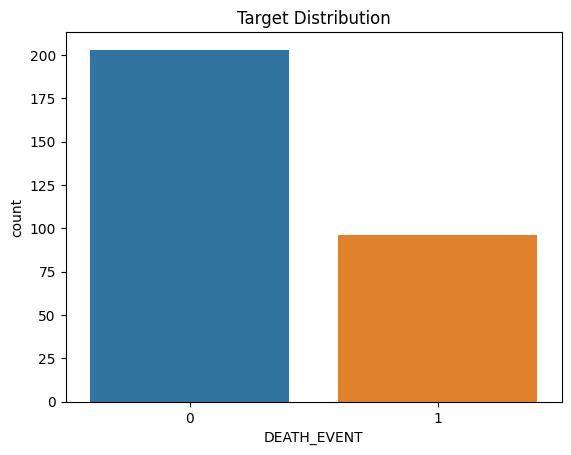

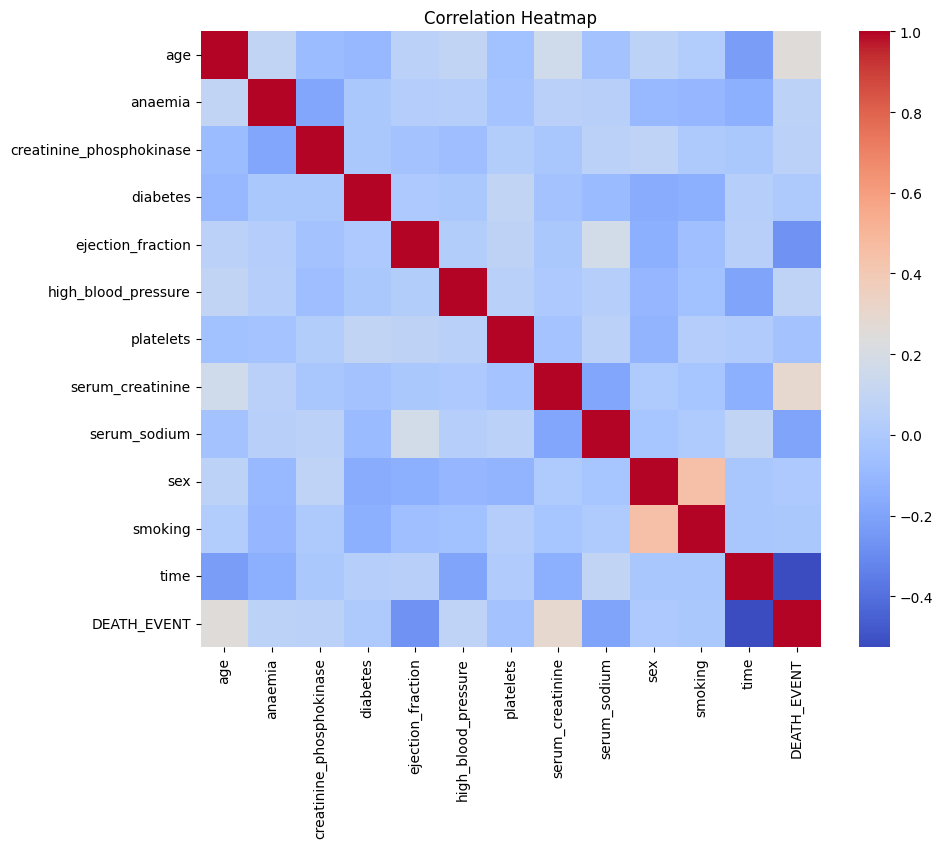

In [8]:
sns.countplot(x=TARGET, data=df)
plt.title("Target Distribution")
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Data Cleaning

#  Train Test Split

In [9]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# Feature Scaling

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Handling Class Imbalance

In [11]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train_scaled, y_train)

# Models

In [12]:
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True, random_state=42),
    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(128, 64),
        max_iter=500,
        early_stopping=True,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

# Grid Search

In [13]:
param_grids = {
    "Random Forest": {
        "n_estimators": [100, 200],
        "max_depth": [None, 5, 10]
    },
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"]
    }
}

best_models = {}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name in param_grids:
        grid = GridSearchCV(
            model,
            param_grids[name],
            scoring="roc_auc",
            cv=cv,
            n_jobs=-1
        )
        grid.fit(X_train_bal, y_train_bal)
        best_models[name] = grid.best_estimator_
        print("Best Params:", grid.best_params_)
    else:
        model.fit(X_train_bal, y_train_bal)
        best_models[name] = model



Training Decision Tree...

Training Naive Bayes...

Training SVM...
Best Params: {'C': 10, 'kernel': 'rbf'}

Training Neural Network...

Training Random Forest...
Best Params: {'max_depth': 10, 'n_estimators': 100}

Training Logistic Regression...


# Evaluation

In [14]:
results = []
roc_data = {}

for name, model in best_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1, roc, bal_acc, mcc, kappa])

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


===== Decision Tree =====
              precision    recall  f1-score   support

           0       0.89      0.78      0.83        41
           1       0.62      0.79      0.70        19

    accuracy                           0.78        60
   macro avg       0.76      0.78      0.76        60
weighted avg       0.81      0.78      0.79        60

Confusion Matrix:
 [[32  9]
 [ 4 15]]

===== Naive Bayes =====
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        41
           1       0.62      0.53      0.57        19

    accuracy                           0.75        60
   macro avg       0.71      0.69      0.70        60
weighted avg       0.74      0.75      0.74        60

Confusion Matrix:
 [[35  6]
 [ 9 10]]

===== SVM =====
              precision    recall  f1-score   support

           0       0.80      0.85      0.82        41
           1       0.62      0.53      0.57        19

    accuracy                         

# Table of result

In [15]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model", "Accuracy", "Precision", "Recall", "F1-score",
        "ROC-AUC", "Balanced Accuracy", "MCC", "Cohen Kappa"
    ]
)

print("\nMODEL COMPARISON")
print(results_df.sort_values(by="ROC-AUC", ascending=False))


MODEL COMPARISON
                 Model  Accuracy  Precision    Recall  F1-score   ROC-AUC  \
4        Random Forest  0.816667   0.722222  0.684211  0.702703  0.896021   
5  Logistic Regression  0.800000   0.733333  0.578947  0.647059  0.865212   
3       Neural Network  0.700000   0.526316  0.526316  0.526316  0.817715   
1          Naive Bayes  0.750000   0.625000  0.526316  0.571429  0.812580   
0        Decision Tree  0.783333   0.625000  0.789474  0.697674  0.784981   
2                  SVM  0.750000   0.625000  0.526316  0.571429  0.766367   

   Balanced Accuracy       MCC  Cohen Kappa  
4           0.781130  0.570748     0.570312  
5           0.740693  0.517143     0.510204  
3           0.653402  0.306804     0.306804  
1           0.689987  0.399702     0.396783  
0           0.784981  0.541199     0.532374  
2           0.689987  0.399702     0.396783  


# ROC curves

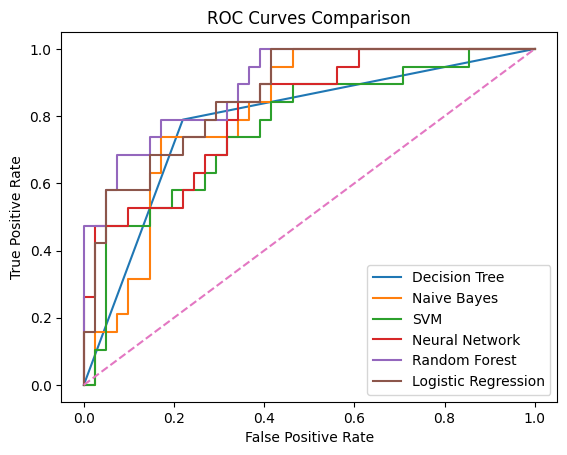

In [16]:
plt.figure()
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=name)

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

# Feature Importance

In [17]:
rf_model = best_models["Random Forest"]

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop Important Features:")
print(feature_importance.head(10))



Top Important Features:
                     Feature  Importance
11                      time    0.314976
7           serum_creatinine    0.204404
4          ejection_fraction    0.134750
2   creatinine_phosphokinase    0.077510
8               serum_sodium    0.070822
0                        age    0.063056
6                  platelets    0.060205
5        high_blood_pressure    0.018816
9                        sex    0.015118
1                    anaemia    0.014257
